In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [2]:
TARGET = "../../data/raw_concat/diabetes.json" # File dữ liệu đã ghép nối lại
INDICATOR_LINKS = "../data/urls/diabetes.txt" # File indicators thô

In [3]:
# Tiến hành đọc dữ liệu
with open(TARGET, "r", encoding="utf-8") as f:
    df = pd.DataFrame(json.load(f))
print(df.describe())

        NumericValue
count  184692.000000
mean       14.650510
std        31.628885
min         0.000000
25%         5.552627
50%         8.674713
75%        16.510621
max      1957.000000


In [6]:
# Thử in thử
df.head()

ParentLocationCode SpatialDim      Dim1             Value  NumericValue  \
0               SEAR        TLS  SEX_FMLE  19.5 [12.4-28.4]          19.5   
1                AMR        TTO  SEX_FMLE  16.7 [14.0-19.3]          16.7   
2               SEAR        IND  SEX_FMLE  18.5 [15.0-23.2]          18.5   
3                EUR        POL  SEX_FMLE  12.2 [11.8-13.2]          12.2   
4               SEAR        BGD  SEX_BTSX  19.1 [11.9-27.8]          19.1   

  TimeDimType  TimeDim IndicatorCode                          Date  
0        YEAR     2002   NCDMORT3070  2024-12-18T14:54:42.07+01:00  
1        YEAR     2004   NCDMORT3070  2024-12-18T14:54:42.07+01:00  
2        YEAR     2014   NCDMORT3070  2024-12-18T14:54:42.07+01:00  
3        YEAR     2010   NCDMORT3070  2024-12-18T14:54:42.07+01:00  
4        YEAR     2000   NCDMORT3070  2024-12-18T14:54:42.07+01:00

In [9]:
# Chương trình xử lý dữ liệu (chuyển đổi giá trị để tiến hành hiển thị)
df["NumericValue"] = pd.to_numeric(df["NumericValue"], errors="coerce")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [14]:
def check_null(frame, fields=["ParentLocationCode", "SpatialDim", "Dim1", "Value", "NumericValue", "Date", "IndicatorCode"]):
    for field in fields:
        num = frame[field].isnull().sum()
        print(f"Trường: {field} có {num} giá trị null!")
check_null(df)

Trường: ParentLocationCode có 8481 giá trị null!
Trường: SpatialDim có 0 giá trị null!
Trường: Dim1 có 4462 giá trị null!
Trường: Value có 0 giá trị null!
Trường: NumericValue có 6082 giá trị null!
Trường: Date có 73888 giá trị null!
Trường: IndicatorCode có 0 giá trị null!


In [15]:
# Tiến hành so sánh giá trị NULL và không NULL của bộ dữ liệu
# Cách tổ chức đẹp hơn là việc viết code trên hiển thị từng dòng
df.isna().sum().to_frame('null_count')

,null_count
ParentLocationCode,8481
SpatialDim,0
Dim1,4462
Value,0
NumericValue,6082
Date,73888
IndicatorCode,0


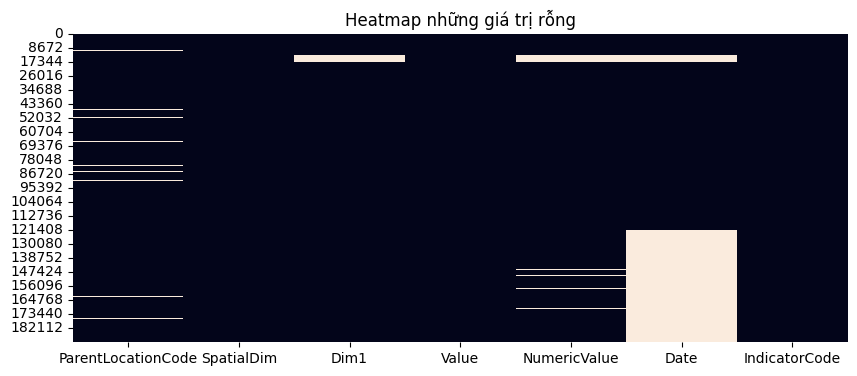

In [18]:
# Tiến hành vẽ hiển thị thử về các giá trị NULL
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Heatmap những giá trị rỗng")
plt.show()

<Axes: >

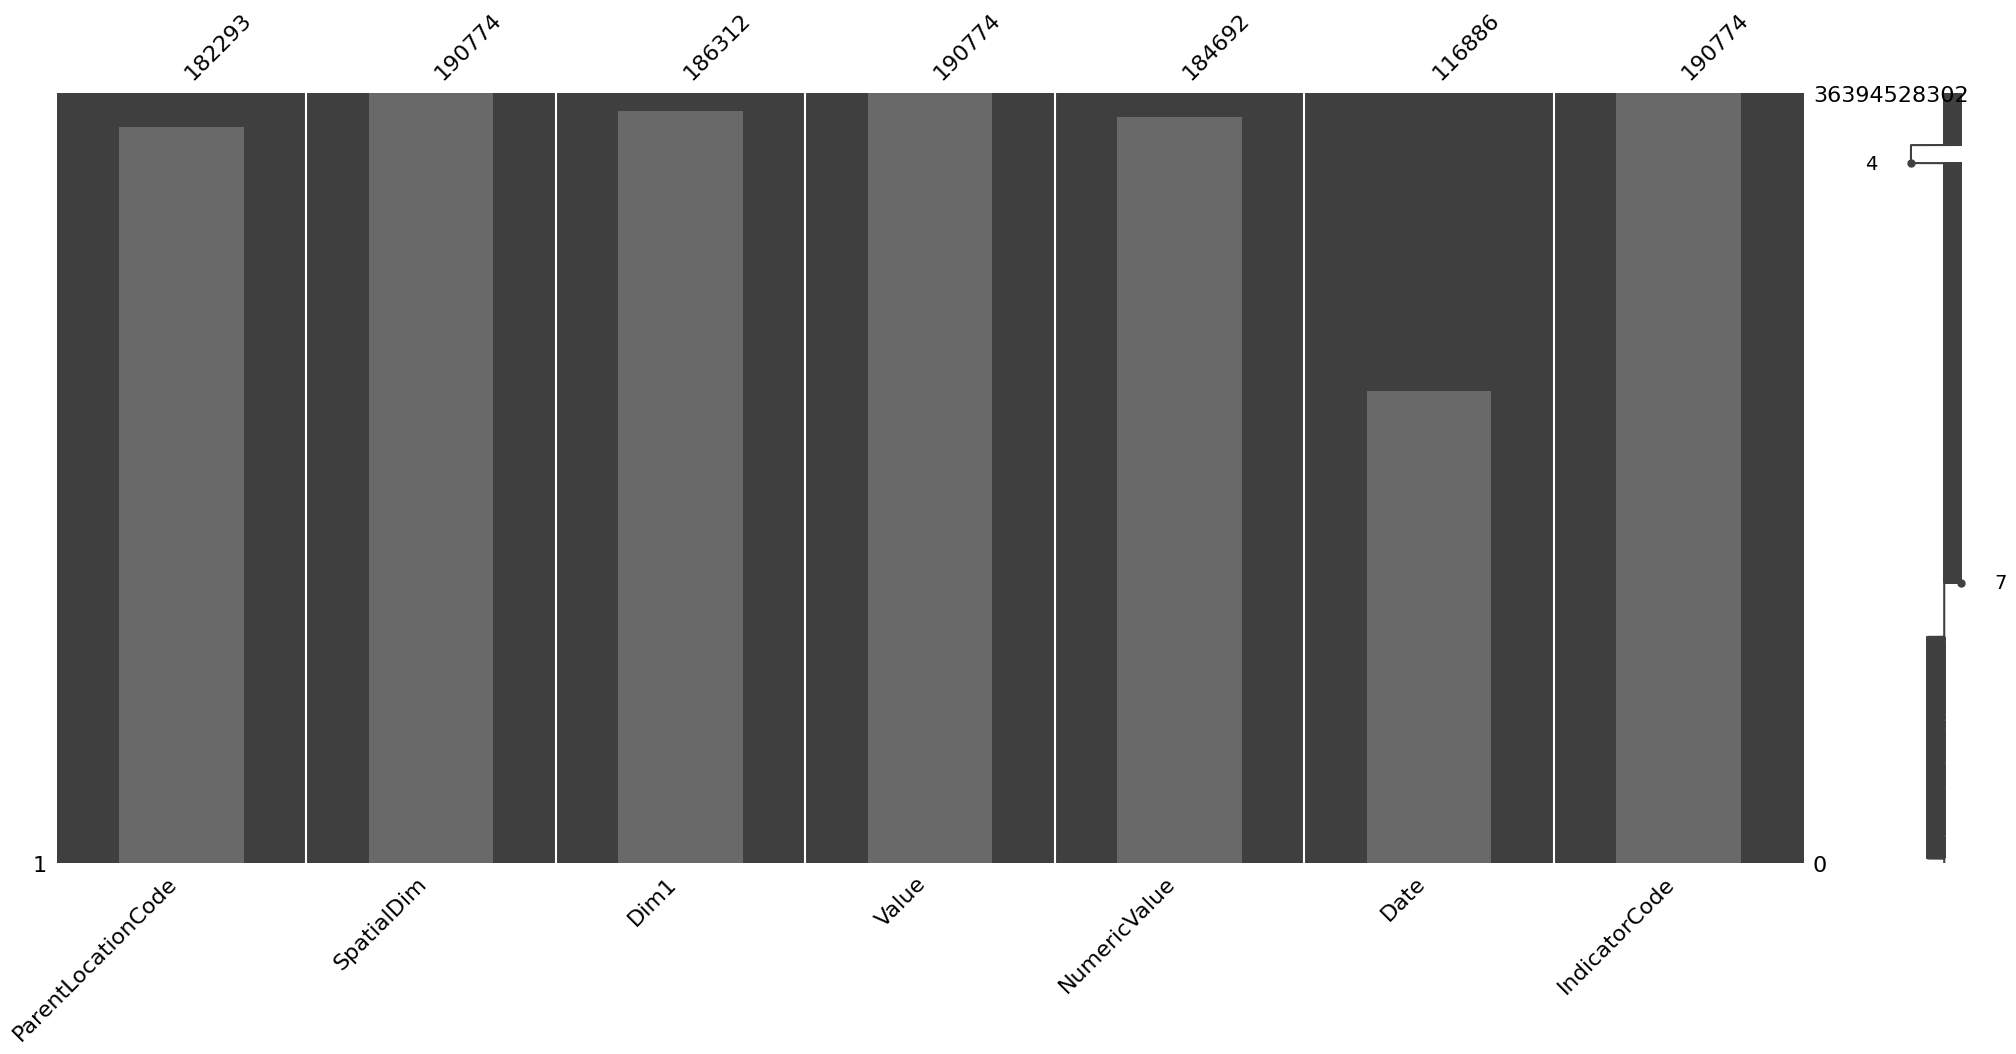

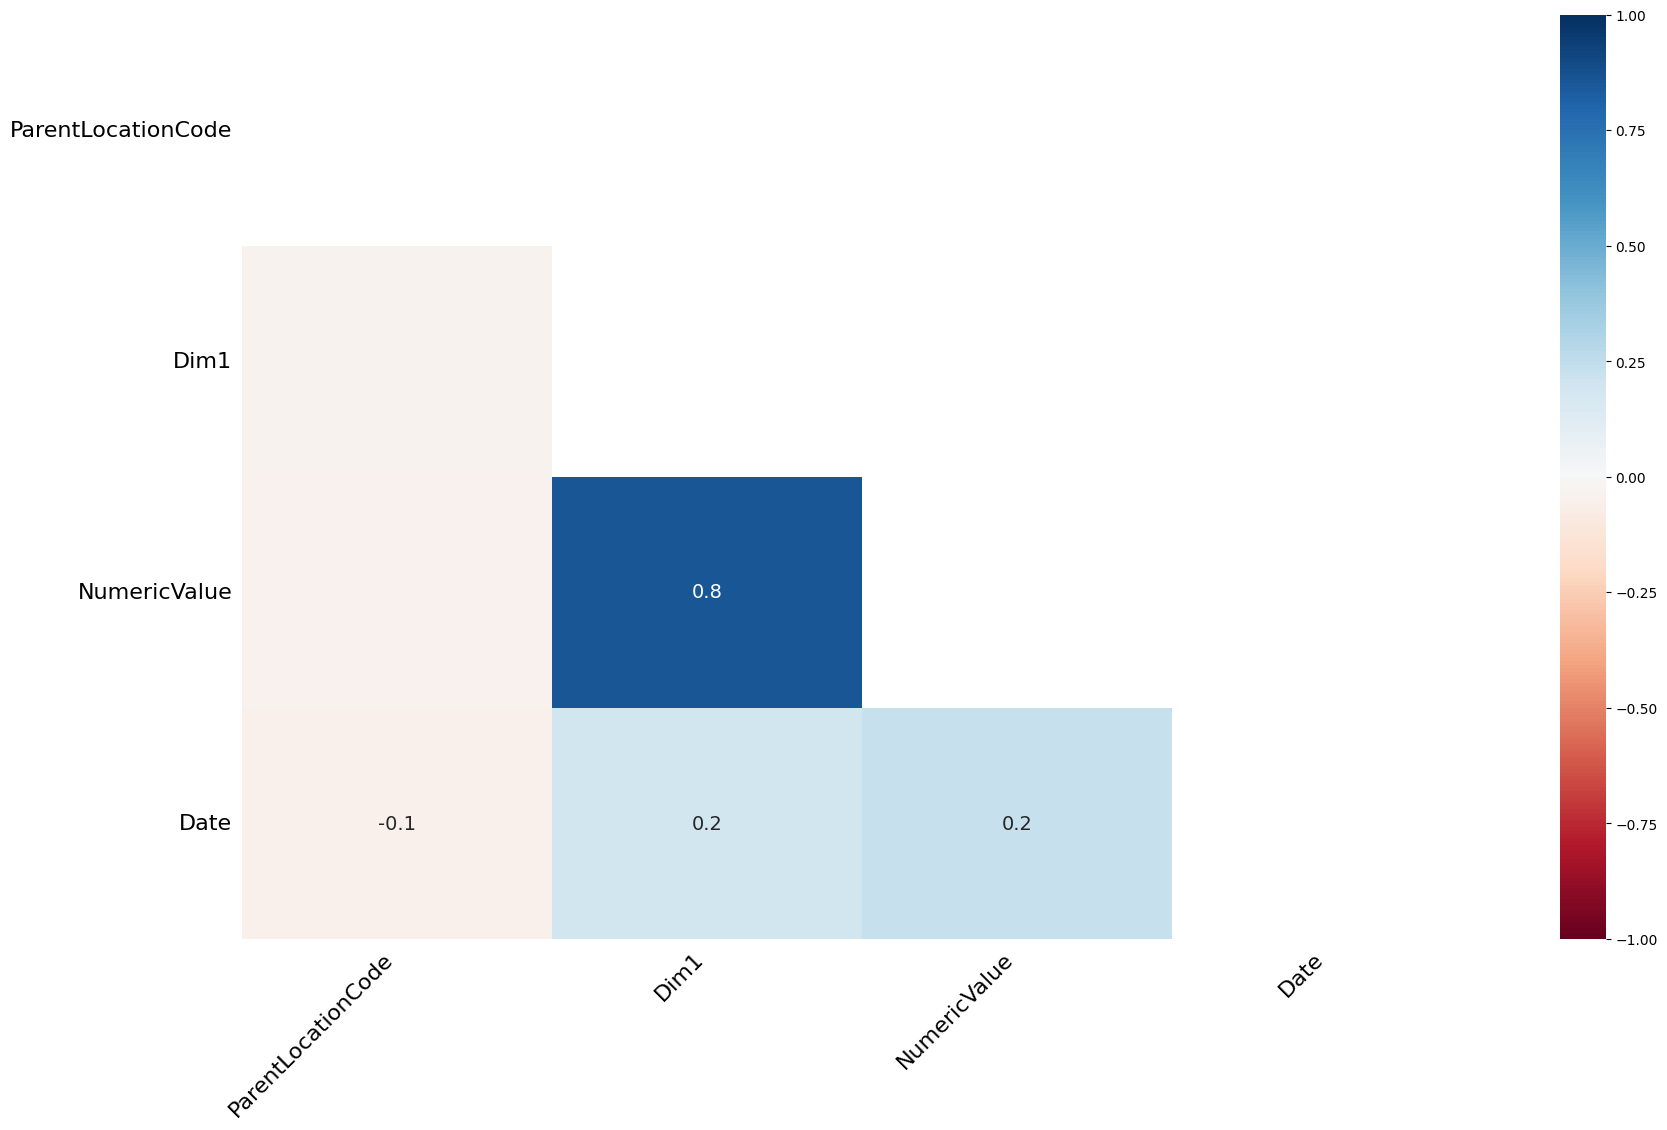

In [20]:
# Sử dụng thư viện bên ngoài để vẽ hiển thị
msno.matrix(df, figsize=(10,4))
msno.bar(df)
msno.heatmap(df)

In [23]:
# Bổ sung thêm cơ sở ra quyết định với loại biểu đồ
df.groupby('Dim1')['NumericValue'].apply(
    lambda x: x.isna().mean()
).sort_values(ascending=False)

Dim1
SEX_FMLE    0.010110
SEX_MLE     0.010110
SEX_BTSX    0.005208
Name: NumericValue, dtype: float64

KeyError: 'Country'

In [ ]:
# Tiến hành xem lại đã xử lí OK chưa?
df.isna().sum()

In [4]:
# Tiến hành hiển thị tương quan
df.corr()

ValueError: could not convert string to float: 'SEAR'